In [21]:
# Import library to fetch stock data from Yahoo Finance
import yfinance as yf  

# Import pandas for data handling
import pandas as pd  

# Import numpy for numerical operations
import numpy as np  

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt  

# Import train-test split function
from sklearn.model_selection import train_test_split  

# Import Linear Regression model
from sklearn.linear_model import LinearRegression  

# Import Random Forest model
from sklearn.ensemble import RandomForestRegressor  

# Import evaluation metric (Mean Squared Error)
from sklearn.metrics import mean_squared_error  

In [22]:
# Download Apple stock data from Yahoo Finance
# "AAPL" is Apple's ticker symbol
stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

# Display first 5 rows of dataset
print(stock.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400513  72.460776  71.156674  71.409778  135480400
2020-01-03  71.696625  72.455943  71.472447  71.629130  146322800
2020-01-06  72.267929  72.306499  70.568503  70.819201  118387200
2020-01-07  71.928070  72.533110  71.708710  72.277594  108872000
2020-01-08  73.085121  73.386438  71.631567  71.631567  132079200


In [23]:
# Create a new column 'Target' which contains next day's closing price
# shift(-1) moves data one step up (future value)
stock['Target'] = stock['Close'].shift(-1)

# Remove last row because it will have NaN (no future value available)
stock = stock.dropna()

# Select input features (independent variables)
# These will be used to predict next day's price
X = stock[['Open', 'High', 'Low', 'Volume']]

# Select target variable (dependent variable)
# This is what we want to predict
y = stock['Target']

In [24]:
# Create target column (next day close)
stock['Target'] = stock['Close'].shift(-1)

# Drop last row (NaN)
stock = stock.dropna()

# Features & target
X = stock[['Open', 'High', 'Low', 'Volume']]
y = stock['Target']

In [25]:
# Create Linear Regression model
lr_model = LinearRegression()

# Train model using training data
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

In [26]:
# Create Random Forest model with 100 trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

In [27]:
# Calculate Mean Squared Error for Linear Regression
print("Linear Regression MSE:", mean_squared_error(y_test, lr_pred))

# Calculate Mean Squared Error for Random Forest
print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))

Linear Regression MSE: 4.945952799357013
Random Forest MSE: 107.43435649433583


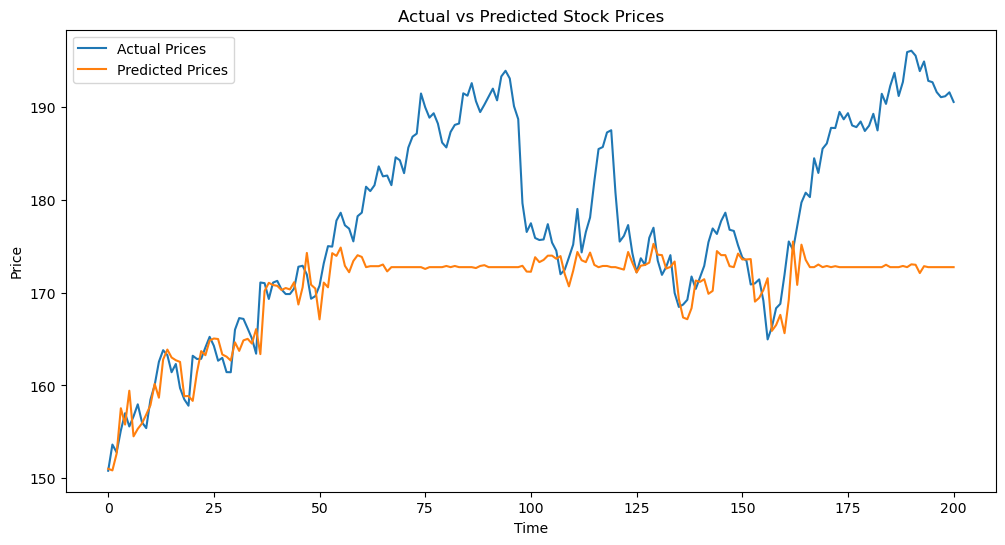

In [28]:
# Create figure with size
plt.figure(figsize=(12,6))

# Plot actual closing prices
plt.plot(y_test.values, label='Actual Prices')

# Plot predicted prices (using Random Forest)
plt.plot(rf_pred, label='Predicted Prices')

# Add title to graph
plt.title("Actual vs Predicted Stock Prices")

# Label X-axis
plt.xlabel("Time")

# Label Y-axis
plt.ylabel("Price")

# Show legend (labels)
plt.legend()

# Display the graph
plt.show()